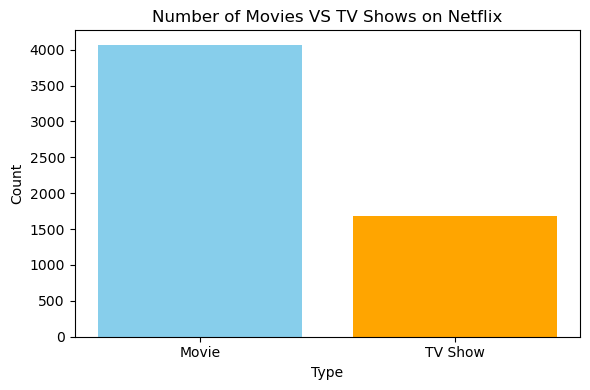

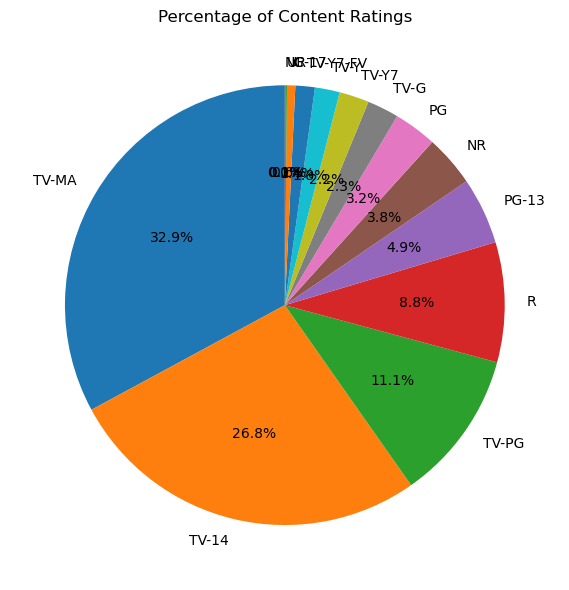

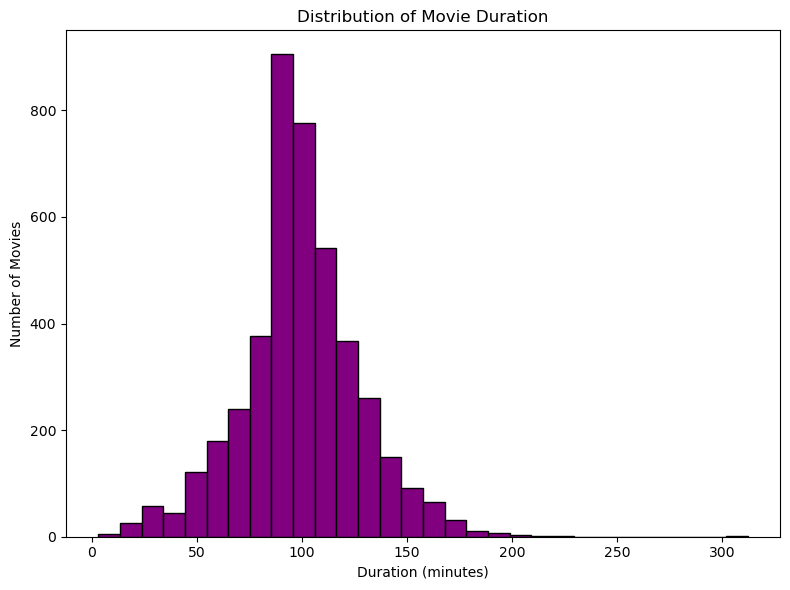

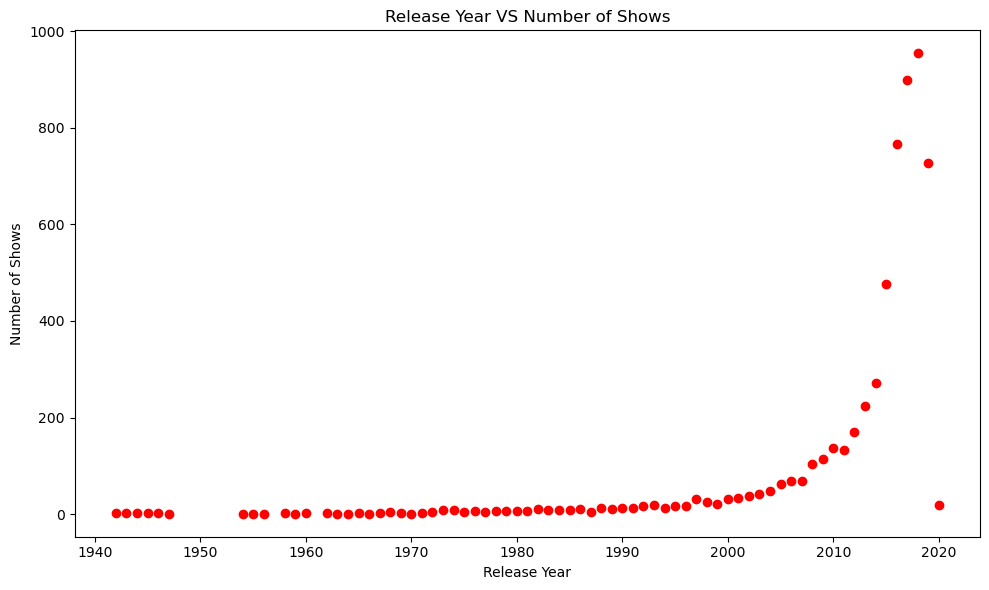

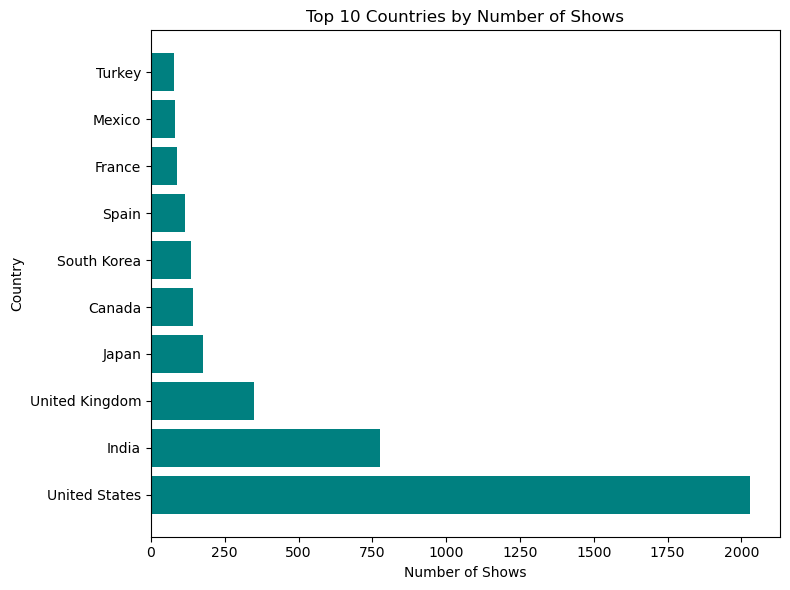

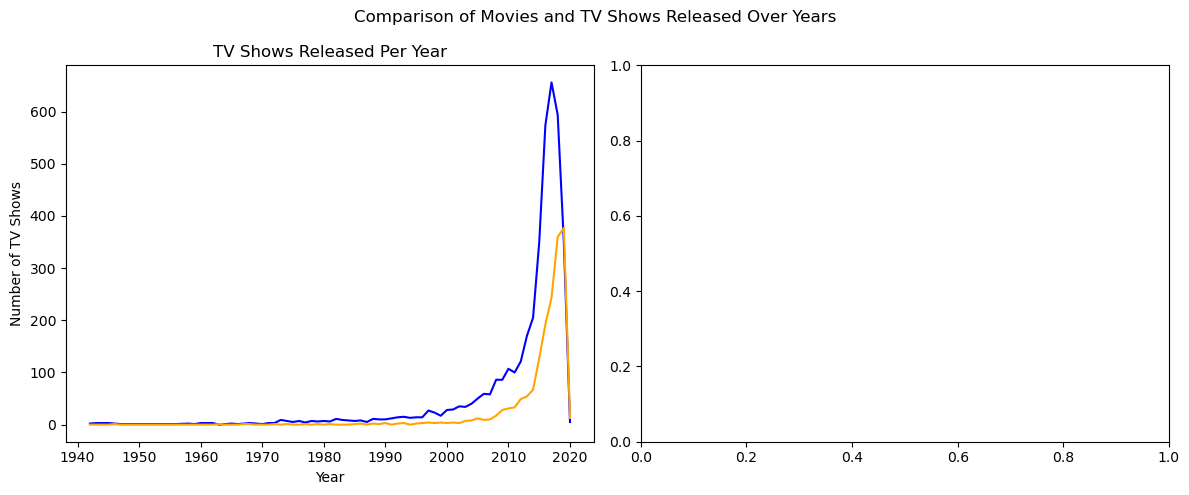

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

#---load the data----

df = pd.read_csv('netflix_titles.csv')

#-----Clean data----
df = df.dropna(subset=['type','release_year','rating','country','duration'])
type_counts = df['type'].value_counts()
plt.figure(figsize=(6,4))
plt.bar(type_counts.index, type_counts.values, color =['skyblue','orange'])
plt.title('Number of Movies VS TV Shows on Netflix')
plt.xlabel('Type')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('movies_vs_tvshows.png')
plt.show()



# ----Pie chart----
rating_counts = df['rating'].value_counts()
plt.figure(figsize =(8,6))
plt.pie(rating_counts, labels= rating_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Percentage of Content Ratings')
plt.tight_layout()
plt.savefig('content_Rating_pie.png')
plt.show()





#----Histogram----
plt.figure(figsize=(8, 6))

plt.hist(
    movie_df['duration_int'],
    bins=30,
    color='purple',
    edgecolor='black'
)

plt.title('Distribution of Movie Duration')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Movies')

plt.tight_layout()
plt.savefig('movie_duration_histogram.png')
plt.show()



#----scatter plot------
release_counts = df['release_year'].value_counts().sort_index()
plt.figure(figsize=(10, 6))

plt.scatter(
    release_counts.index,
    release_counts.values,
    color='red'
)
plt.title('Release Year VS Number of Shows')
plt.xlabel('Release Year')
plt.ylabel('Number of Shows')

plt.tight_layout()
plt.savefig('release_year_scatter.png')
plt.show()




# ---TOP 10 COUNTRIES---
country_counts =df['country'].value_counts().head(10)
plt.figure(figsize=(8,6))
plt.barh(country_counts.index, country_counts.values, color ='teal')
plt.title('Top 10 Countries by Number of Shows')
plt.xlabel('Number of Shows')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('top10_countries.png')
plt.show()





#----RELEASE YEAR---
content_by_year = df.groupby(['release_year','type']).size().unstack().fillna(0)
fig, ax= plt.subplots(1,2, figsize=(12,5))


#---first subplot:Movies---
ax[0].plot(content_by_year.index, content_by_year['Movie'], color ='blue')
ax[0].set_title('Moive Released Per Year')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Number of Movies')



#----Second subplot:TV Shows---
ax[0].plot(content_by_year.index, content_by_year['TV Show'], color ='orange')
ax[0].set_title('TV Shows Released Per Year')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Number of TV Shows')

fig.suptitle('Comparison of Movies and TV Shows Released Over Years')
plt.tight_layout()
plt.savefig('movies_tv_shows_comparison.png')
plt.show()
